In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


In [2]:
# 2. LOAD DATASET
df = pd.read_csv("datasets/housing.csv")

print("First rows:")
print(df.head())


First rows:
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0       79545.45857             5.682861                   7.009188   
1       79248.64245             6.002900                   6.730821   
2       61287.06718             5.865890                   8.512727   
3       63345.24005             7.188236                   5.586729   
4       59982.19723             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09      23086.80050  1.059034e+06   
1                          3.09      40173.07217  1.505891e+06   
2                          5.13      36882.15940  1.058988e+06   
3                          3.26      34310.24283  1.260617e+06   
4                          4.23      26354.10947  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  

In [3]:
# 3. FEATURE ENGINEERING

# --- A. ENCODING (Address not useful → drop) ---
df = df.drop("Address", axis=1)

# --- B. CREATE CLASSIFICATION TARGET ---
# Convert Price → High (1) / Low (0)
median_price = df["Price"].median()
df["Price_Category"] = (df["Price"] > median_price).astype(int)

In [4]:
# 4. FEATURES vs LABEL
X = df.drop(["Price", "Price_Category"], axis=1)
y = df["Price_Category"]

In [5]:
# 5. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# 6. SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# 7. MODEL TRAINING
model = LogisticRegression(max_iter=99999999999)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=99999999999)

In [11]:
# 8. PREDICTION
y_pred = model.predict(X_test_scaled)

In [13]:
# 9. EVALUATION METRICS
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)


print("\n=== MODEL EVALUATION ===")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)



=== MODEL EVALUATION ===
Accuracy: 0.905
Precision: 0.914396887159533
Recall: 0.9021113243761996


In [14]:
# 10. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[435  44]
 [ 51 470]]


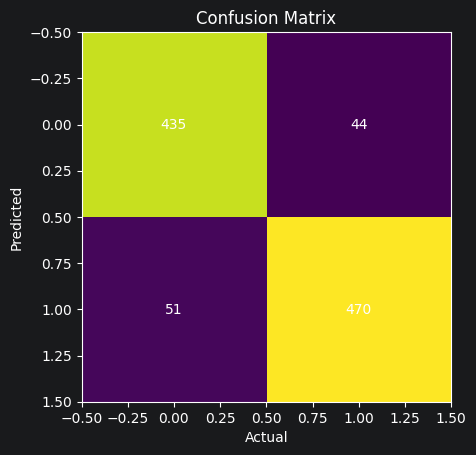

In [19]:
# 11. VISUALIZE CONFUSION MATRIX
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Actual")
plt.ylabel("Predicted")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.show()

In [18]:
# 12. MIN-MAX SCALING (OPTIONAL COMPARISON)
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

model_mm = LogisticRegression(max_iter=1000)
model_mm.fit(X_train_mm, y_train)

y_pred_mm = model_mm.predict(X_test_mm)

print("\nMinMax Accuracy:", accuracy_score(y_test, y_pred_mm))


MinMax Accuracy: 0.902


## 🧠 1. Why this matters

This pipeline shows how to:

- Improve model performance
- Prepare data correctly
- Evaluate models properly

---

## 📊 2. Accuracy, Precision, Recall

### ✔ Accuracy
- % of correct predictions
- Good when classes are balanced

### ✔ Precision
- Of predicted positives → how many are correct
- Important when false positives are costly

### ✔ Recall
- Of actual positives → how many detected
- Important when missing cases is risky

### ✔ Why important:
- Shows type of mistakes
- Helps improve model

---

## 🔤 4. Encoding

### ✔ Why:
Models cannot understand text

### ✔ In this dataset:
- `Address` dropped (not useful)
- Created a numerical target variable for classification

---

## ⚖️ 5. Scaling

### ✔ StandardScaler
- Mean = 0
- Std = 1

### ✔ MinMaxScaler
- Range: 0 → 1

### ✔ Why:
- Prevents large values dominating
- Helps model converge better

---

## 🧠 6. Key Insights

- Accuracy alone is not enough
- Precision & Recall give deeper understanding
- Confusion matrix shows errors clearly
- Feature engineering improves learning
- Scaling improves performance

---

## 🚀 What you just built (important)

You now have:

- ✔ Classification pipeline
- ✔ Feature engineering
- ✔ Model evaluation system
- ✔ Visualization (confusion matrix)